<a href="https://colab.research.google.com/github/szmygielski/lecture1/blob/main/PUM_13_27_04_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [5]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
y = data.target #list(data.target_names)
X = data.data #data.feature_names

1. Sprawdź liczbę wszystkich przypadków

In [6]:
print(f"Total number of cases: {len(y)}")
print(f"Feature matrix shape: {X.shape}")

Total number of cases: 569
Feature matrix shape: (569, 30)


2. Sprawdź liczbę przypadków raka złośliwego

In [7]:
import seaborn as sns

zlosliwy_count = np.sum(y == 0)
lagodny_count = np.sum(y == 1)
print(f"Liczba przypadków złośliwych: {zlosliwy_count}")
print(f"Liczba przypadków łagodnych: {lagodny_count}")

Liczba przypadków złośliwych: 212
Liczba przypadków łagodnych: 357


3. Narysuj histogram średniego obszaru (mean area)

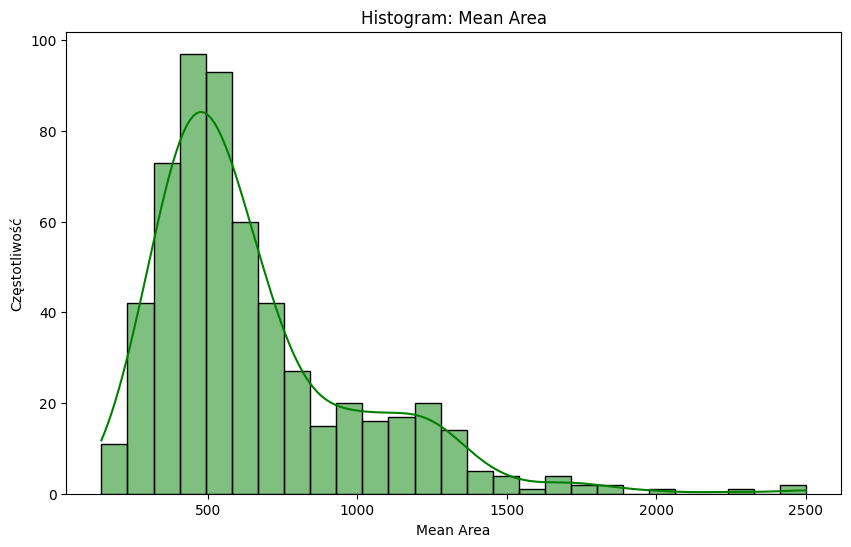

In [8]:
mean_area_index = list(data.feature_names).index('mean area')

plt.figure(figsize=(10, 6))
sns.histplot(X[:, mean_area_index], kde=True, color='green')
plt.title('Histogram: Mean Area')
plt.xlabel('Mean Area')
plt.ylabel('Częstotliwość')
plt.show()

4. Narysuj wykres rozrzutu (scatterplot) średniego obszaru od klasyfikacji (użyj
sns.regplot)

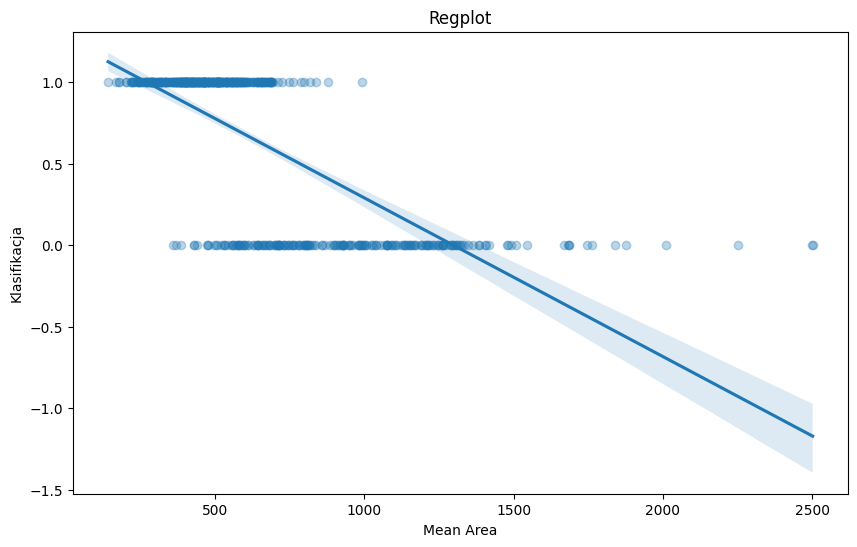

In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(x=X[:, mean_area_index], y=y, scatter_kws={'alpha':0.3})
plt.title('Regplot')
plt.xlabel('Mean Area')
plt.ylabel('Klasifikacja')
plt.show()

Zbuduj model regresji logistycznej

In [10]:
from sklearn.linear_model import LogisticRegression

1. Sprawdź, jeśli dane nie są ustandaryzowane zrób to

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_train, y_test, x_train, x_test = train_test_split(y, X_scaled, test_size = 0.3, random_state = 42)

2. Podziel zbiór danych na testowy (30%) i uczący (70%)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (398, 30)
Testing set shape: (171, 30)


3. Zwizualizuj wyniki używając:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import RocCurveDisplay, roc_curve

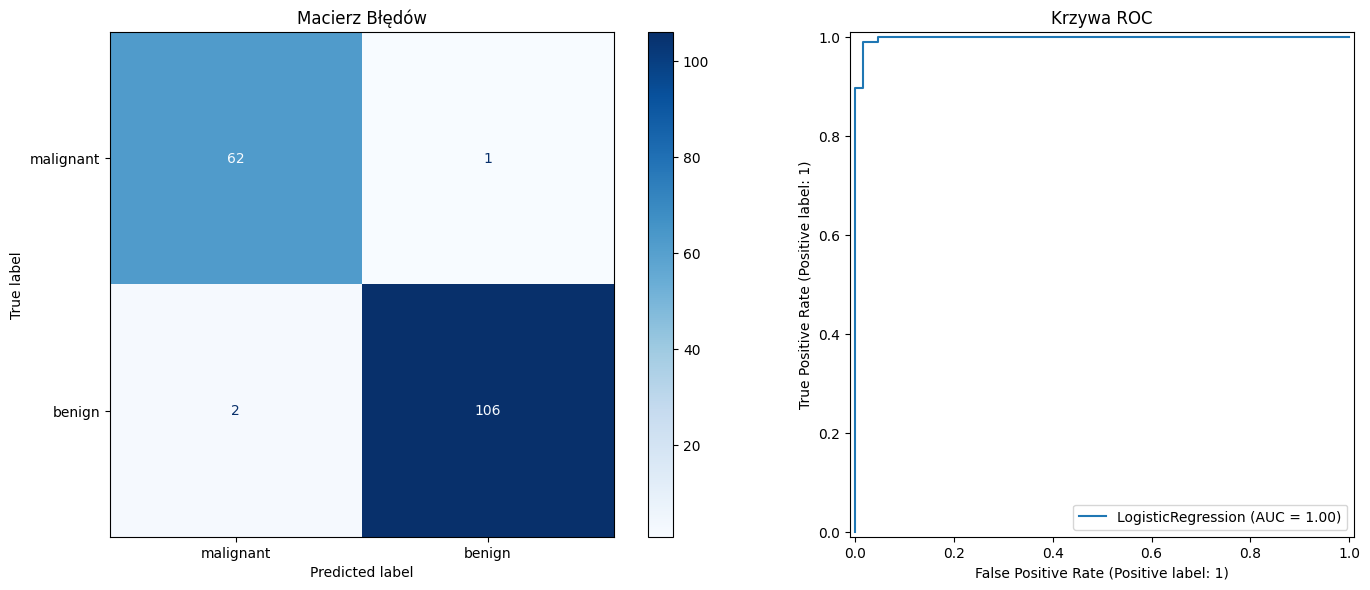

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve

# Trenowanie modelu
model = LogisticRegression()
model.fit(X_train, y_train)

# Przygotowanie wykresów
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Macierz błędów (Confusion Matrix)
cm = confusion_matrix(y_test, model.predict(X_test))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
cmd.plot(ax=ax1, cmap='Blues')
ax1.set_title('Macierz Błędów')

# 2. Krzywa ROC
roc_disp = RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2)
ax2.set_title('Krzywa ROC')

plt.tight_layout()
plt.show()

Porównaj klasyfikatory regresji logistycznej i knn metodą ROC i AUC

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

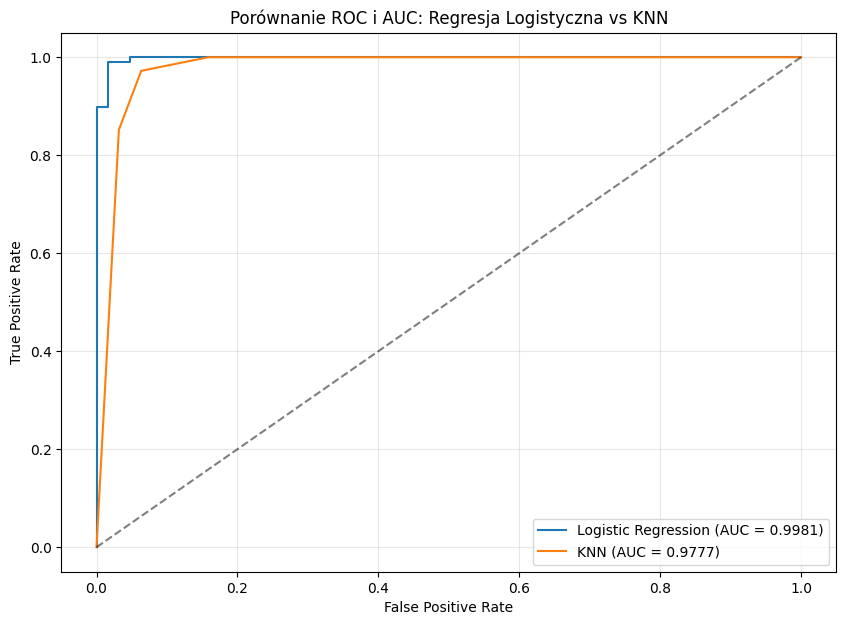

In [15]:
from sklearn.metrics import roc_auc_score

# Inicjalizacja i trenowanie KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prawdopodobieństwa dla obu modeli
y_score_logreg = model.predict_proba(X_test)[:, 1]
y_score_knn = knn.predict_proba(X_test)[:, 1]

# Obliczanie krzywych ROC i AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_logreg)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# Wizualizacja porównawcza
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Porównanie ROC i AUC: Regresja Logistyczna vs KNN')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Drzewo decyzyjne
accuracy: 0.9415
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171


Las losowy
accuracy: 0.9708
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



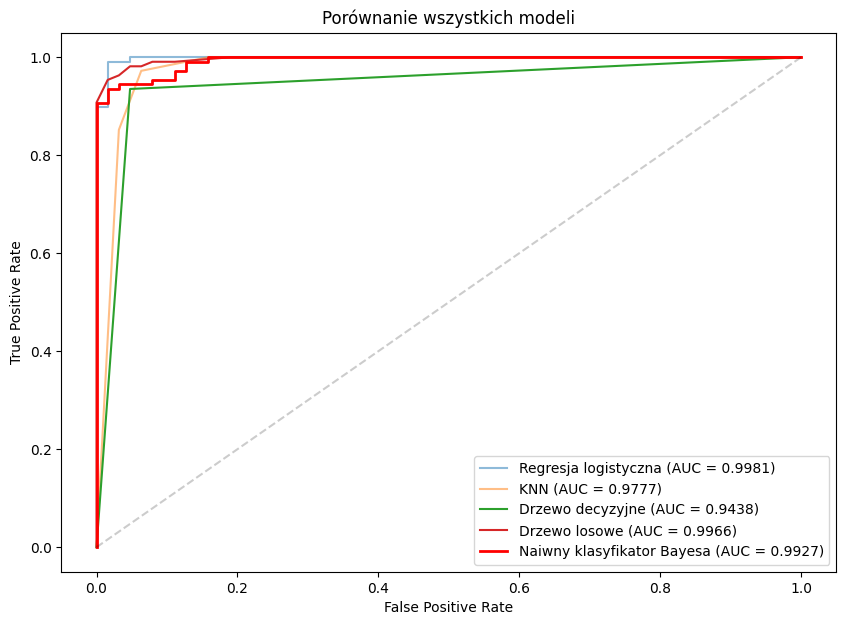

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#drzewo decyzyjne
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

#las losowy
rf_model = RandomForestClassifier(n_estimators=15, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

print("Drzewo decyzyjne")
print(f"accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(classification_report(y_test, dt_preds))

print("\nLas losowy")
print(f"accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))

y_score_dt = dt_model.predict_proba(X_test)[:, 1]
y_score_rf = rf_model.predict_proba(X_test)[:, 1]
y_score_nb = nb_model.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_score_nb)
auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Regresja logistyczna (AUC = {auc_lr:.4f})', alpha=0.5)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})', alpha=0.5)
plt.plot(fpr_dt, tpr_dt, label=f'Drzewo decyzyjne (AUC = {auc(fpr_dt, tpr_dt):.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Drzewo losowe (AUC = {auc(fpr_rf, tpr_rf):.4f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naiwny klasyfikator Bayesa (AUC = {auc_nb:.4f})', linewidth=2, color='red')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Porównanie wszystkich modeli')
plt.legend(loc='lower right')
plt.show()